In [2]:
import os
import glob
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

TIMESTAMP = "20260913182453"

current_dir = os.getcwd()
if not os.path.exists(os.path.join(current_dir, 'src')):
    root_dir = os.path.abspath(os.path.join(current_dir, '..'))
    os.chdir(root_dir)

LOG_DIR = os.path.join("data", "augmented", TIMESTAMP, "augmented_log")
MERGED_DIR = os.path.join("data", "augmented", TIMESTAMP, "merged", "balanced")
RAW_DATA_PATH = os.path.join("data", "raw", "sms_spam_indo.csv")

output_fig_dir = os.path.join("results", "figures")
output_tbl_dir = os.path.join("results", "tables")
os.makedirs(output_fig_dir, exist_ok=True)
os.makedirs(output_tbl_dir, exist_ok=True)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 300,           
    'savefig.dpi': 300,
    'axes.spines.top': False,     
    'axes.spines.right': False,  
    'font.family': 'serif',
})

def export_table_to_png(df, filename, title=None, wrap_width=60):
    df_plot = df.copy()
    
    for col in df_plot.columns:
        if df_plot[col].dtype == 'object':
            df_plot[col] = df_plot[col].apply(lambda x: textwrap.fill(str(x), width=wrap_width) if pd.notnull(x) else x)
            
    fig_width = min(max(len(df_plot.columns) * 2.5, 8), 20)
    fig_height = min(max(len(df_plot) * 0.5 + 1.5, 3), 25)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    
    if title:
        ax.set_title(title, fontweight='bold', fontsize=14, pad=15)
    
    table = ax.table(cellText=df_plot.values, colLabels=df_plot.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    
    for (i, j), cell in table.get_celld().items():
        cell.set_edgecolor('black')
        cell.set_linewidth(0)
        if i == 0:
            cell.set_text_props(weight='bold')
            cell.visible_edges = 'BT'
            cell.set_linewidth(1.5)
        elif i == len(df_plot):
            cell.visible_edges = 'B'
            cell.set_linewidth(1.5)
            
    plt.savefig(os.path.join(output_tbl_dir, filename), bbox_inches='tight')
    plt.close()
    print(f"[*] Tabel diekspor: results/tables/{filename}")

def parse_model_technique(filename):
    name = filename.replace('balanced_', '').replace('log_', '').replace('synthetic_', '').replace('.csv', '')
    techniques = ['zero-shot', 'few-shot', 'role-prompting']
    tech = 'Unknown'
    for t in techniques:
        if t in name:
            tech = t
            name = name.replace(f'_{t}', '')
            break
    model = name.replace('_', ' ').strip()
    return model, tech

print(f"Setup Selesai. Target Timestamp: {TIMESTAMP}")

Setup Selesai. Target Timestamp: 20260913182453


Memproses data klasifikasi dari: data\augmented\20260913182453\merged\balanced
Melatih Model Klasifikasi XGBoost...
[*] Tabel diekspor: results/tables/20260913182453_tbl_classification.png


,Model,Teknik,Akurasi,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,None,0.9432,0.9554,0.9304,0.9427,0.9921
1,GPT 3.5 Turbo,few-shot,0.9658,0.9725,0.9592,0.9658,0.9949
2,GPT 3.5 Turbo,role-prompting,0.9549,0.9666,0.9429,0.9546,0.9872
3,GPT 3.5 Turbo,zero-shot,0.9631,0.9671,0.9592,0.9632,0.9912
4,GPT 4.1,few-shot,0.9699,0.9806,0.9592,0.9698,0.9979
5,GPT 4.1,role-prompting,0.9740,0.9888,0.9592,0.9738,0.9970
6,GPT 4.1,zero-shot,0.9768,0.9889,0.9647,0.9766,0.9982
7,LLaMA2 7B,few-shot,0.9399,0.9551,0.9239,0.9392,0.9883
8,LLaMA2 7B,role-prompting,0.9372,0.9600,0.9130,0.9359,0.9815
9,LLaMA2 7B,zero-shot,0.9631,0.9697,0.9565,0.9631,0.9914


[*] Grafik Gabungan Klasifikasi diekspor: 20260913182453_clf_combined.png


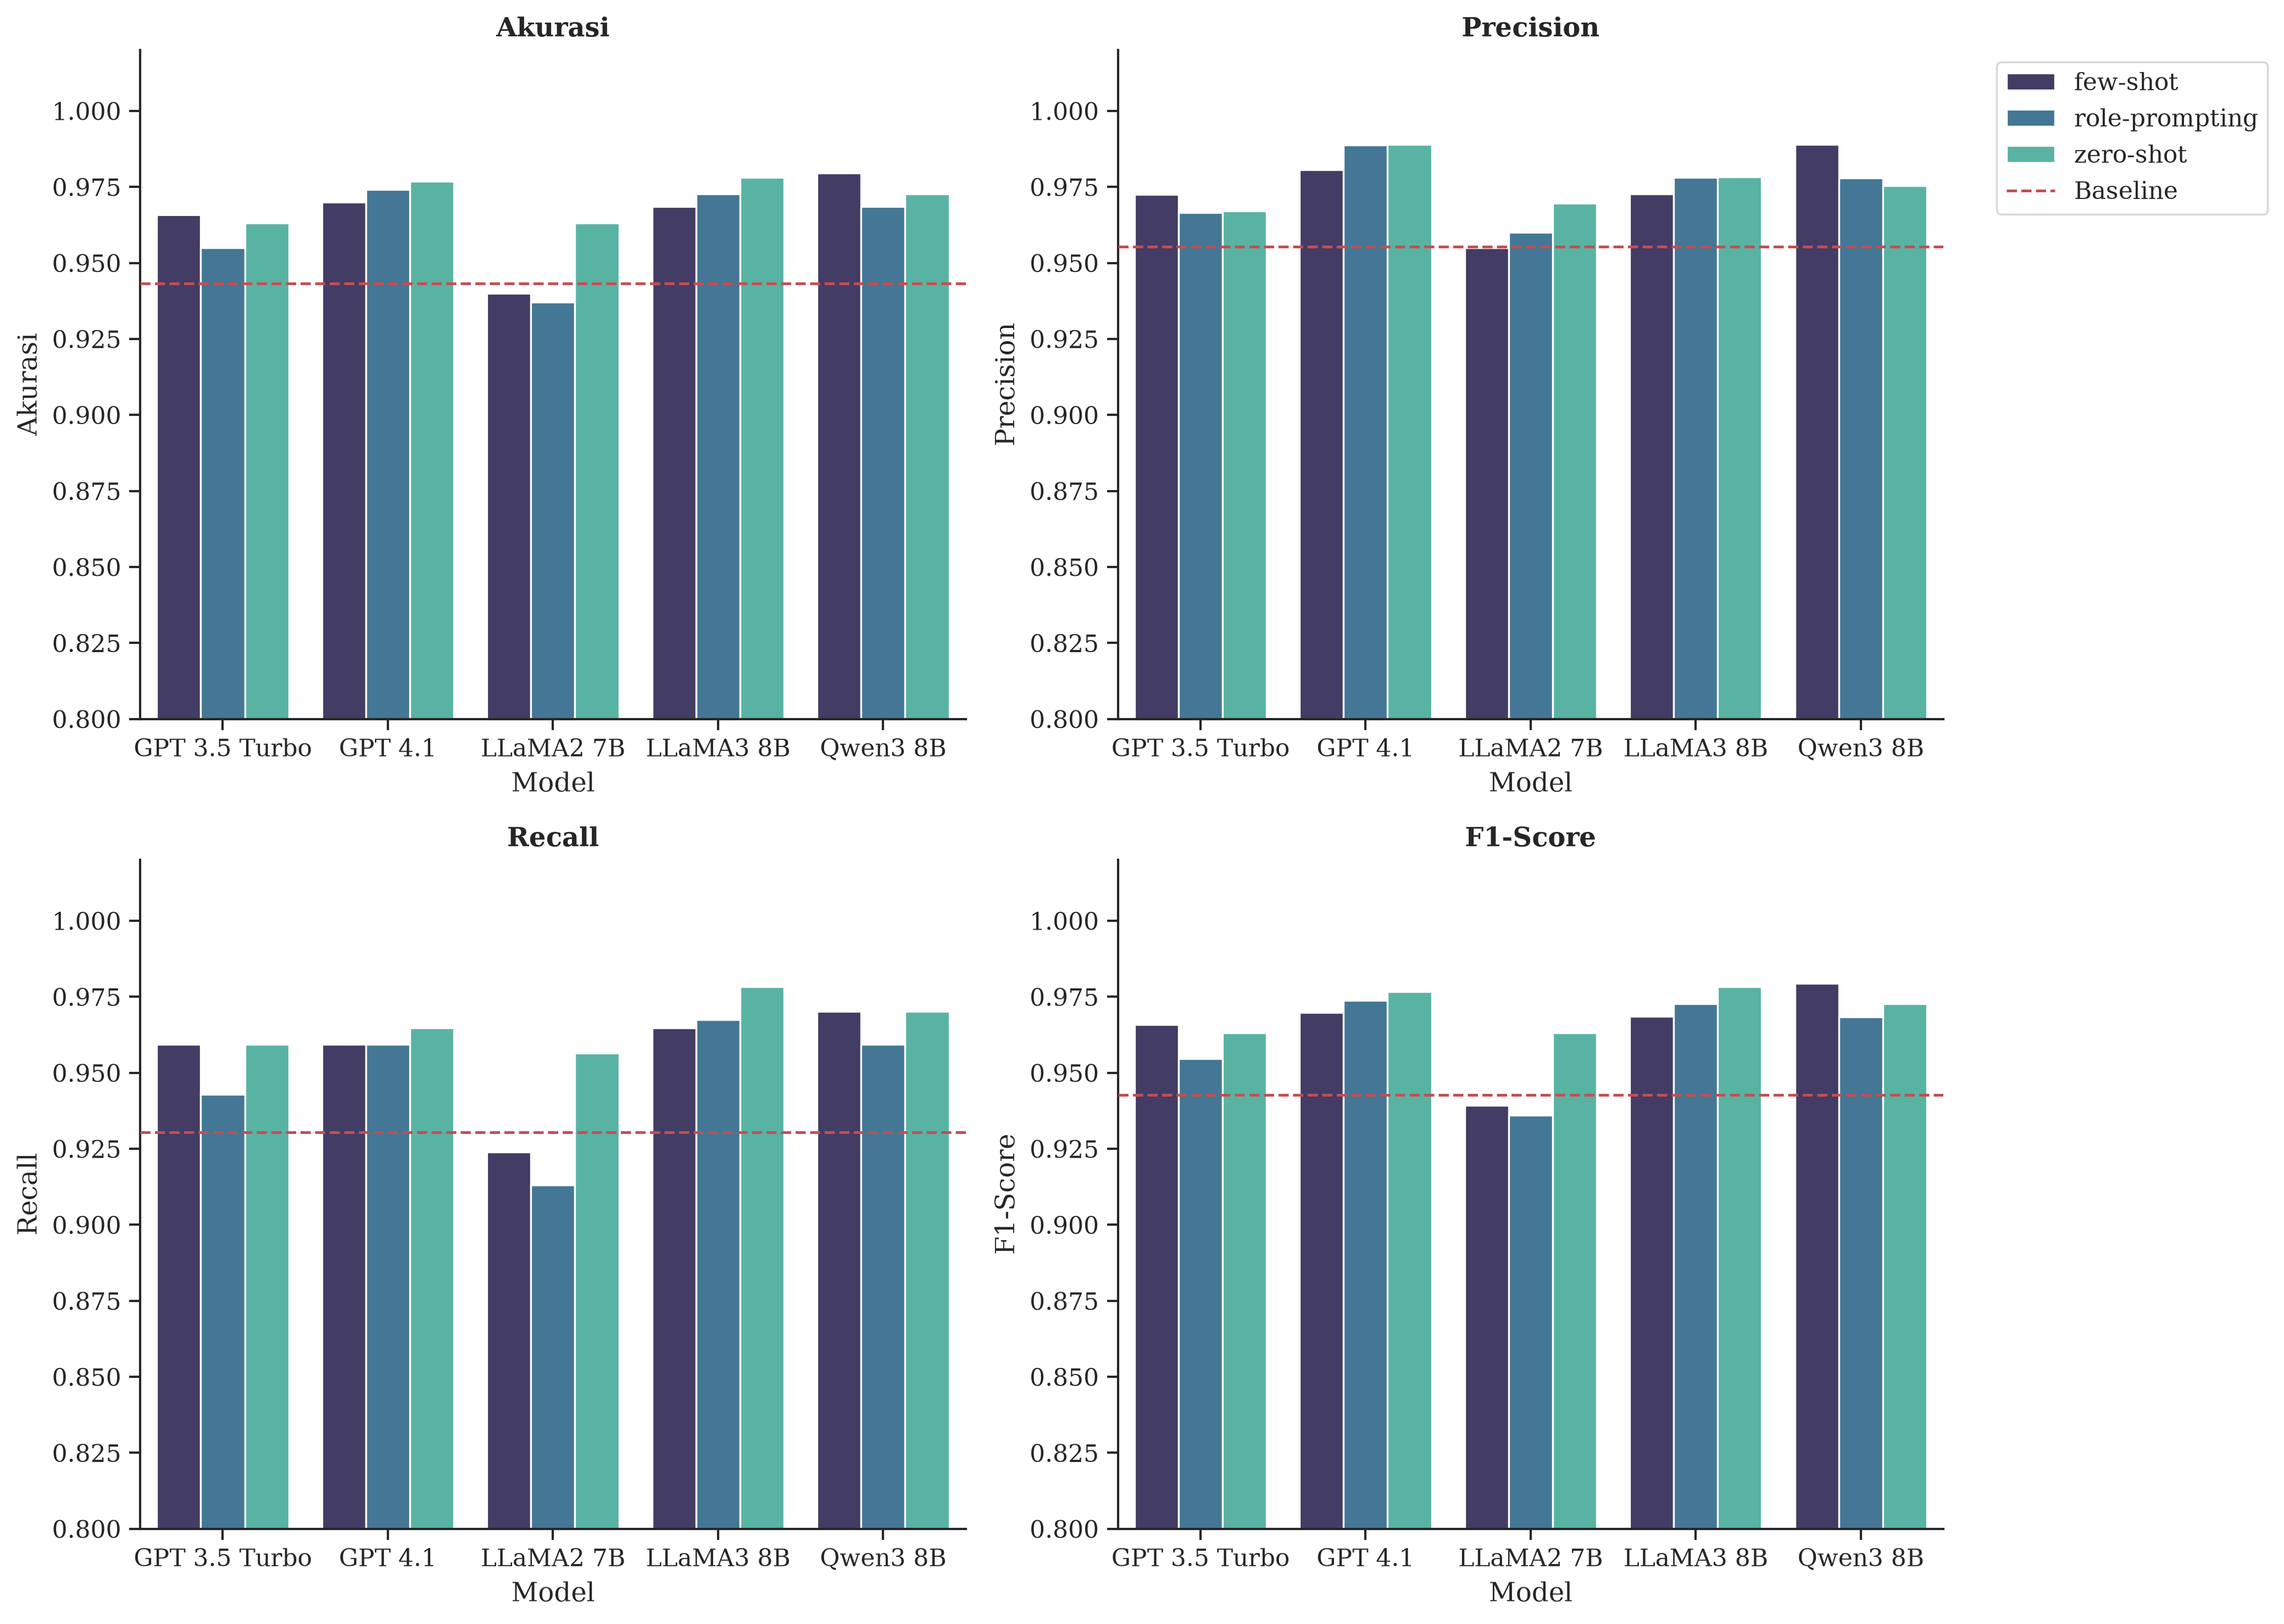

[*] Grafik ROC Curve diekspor: 20260913182453_roc_curve.png


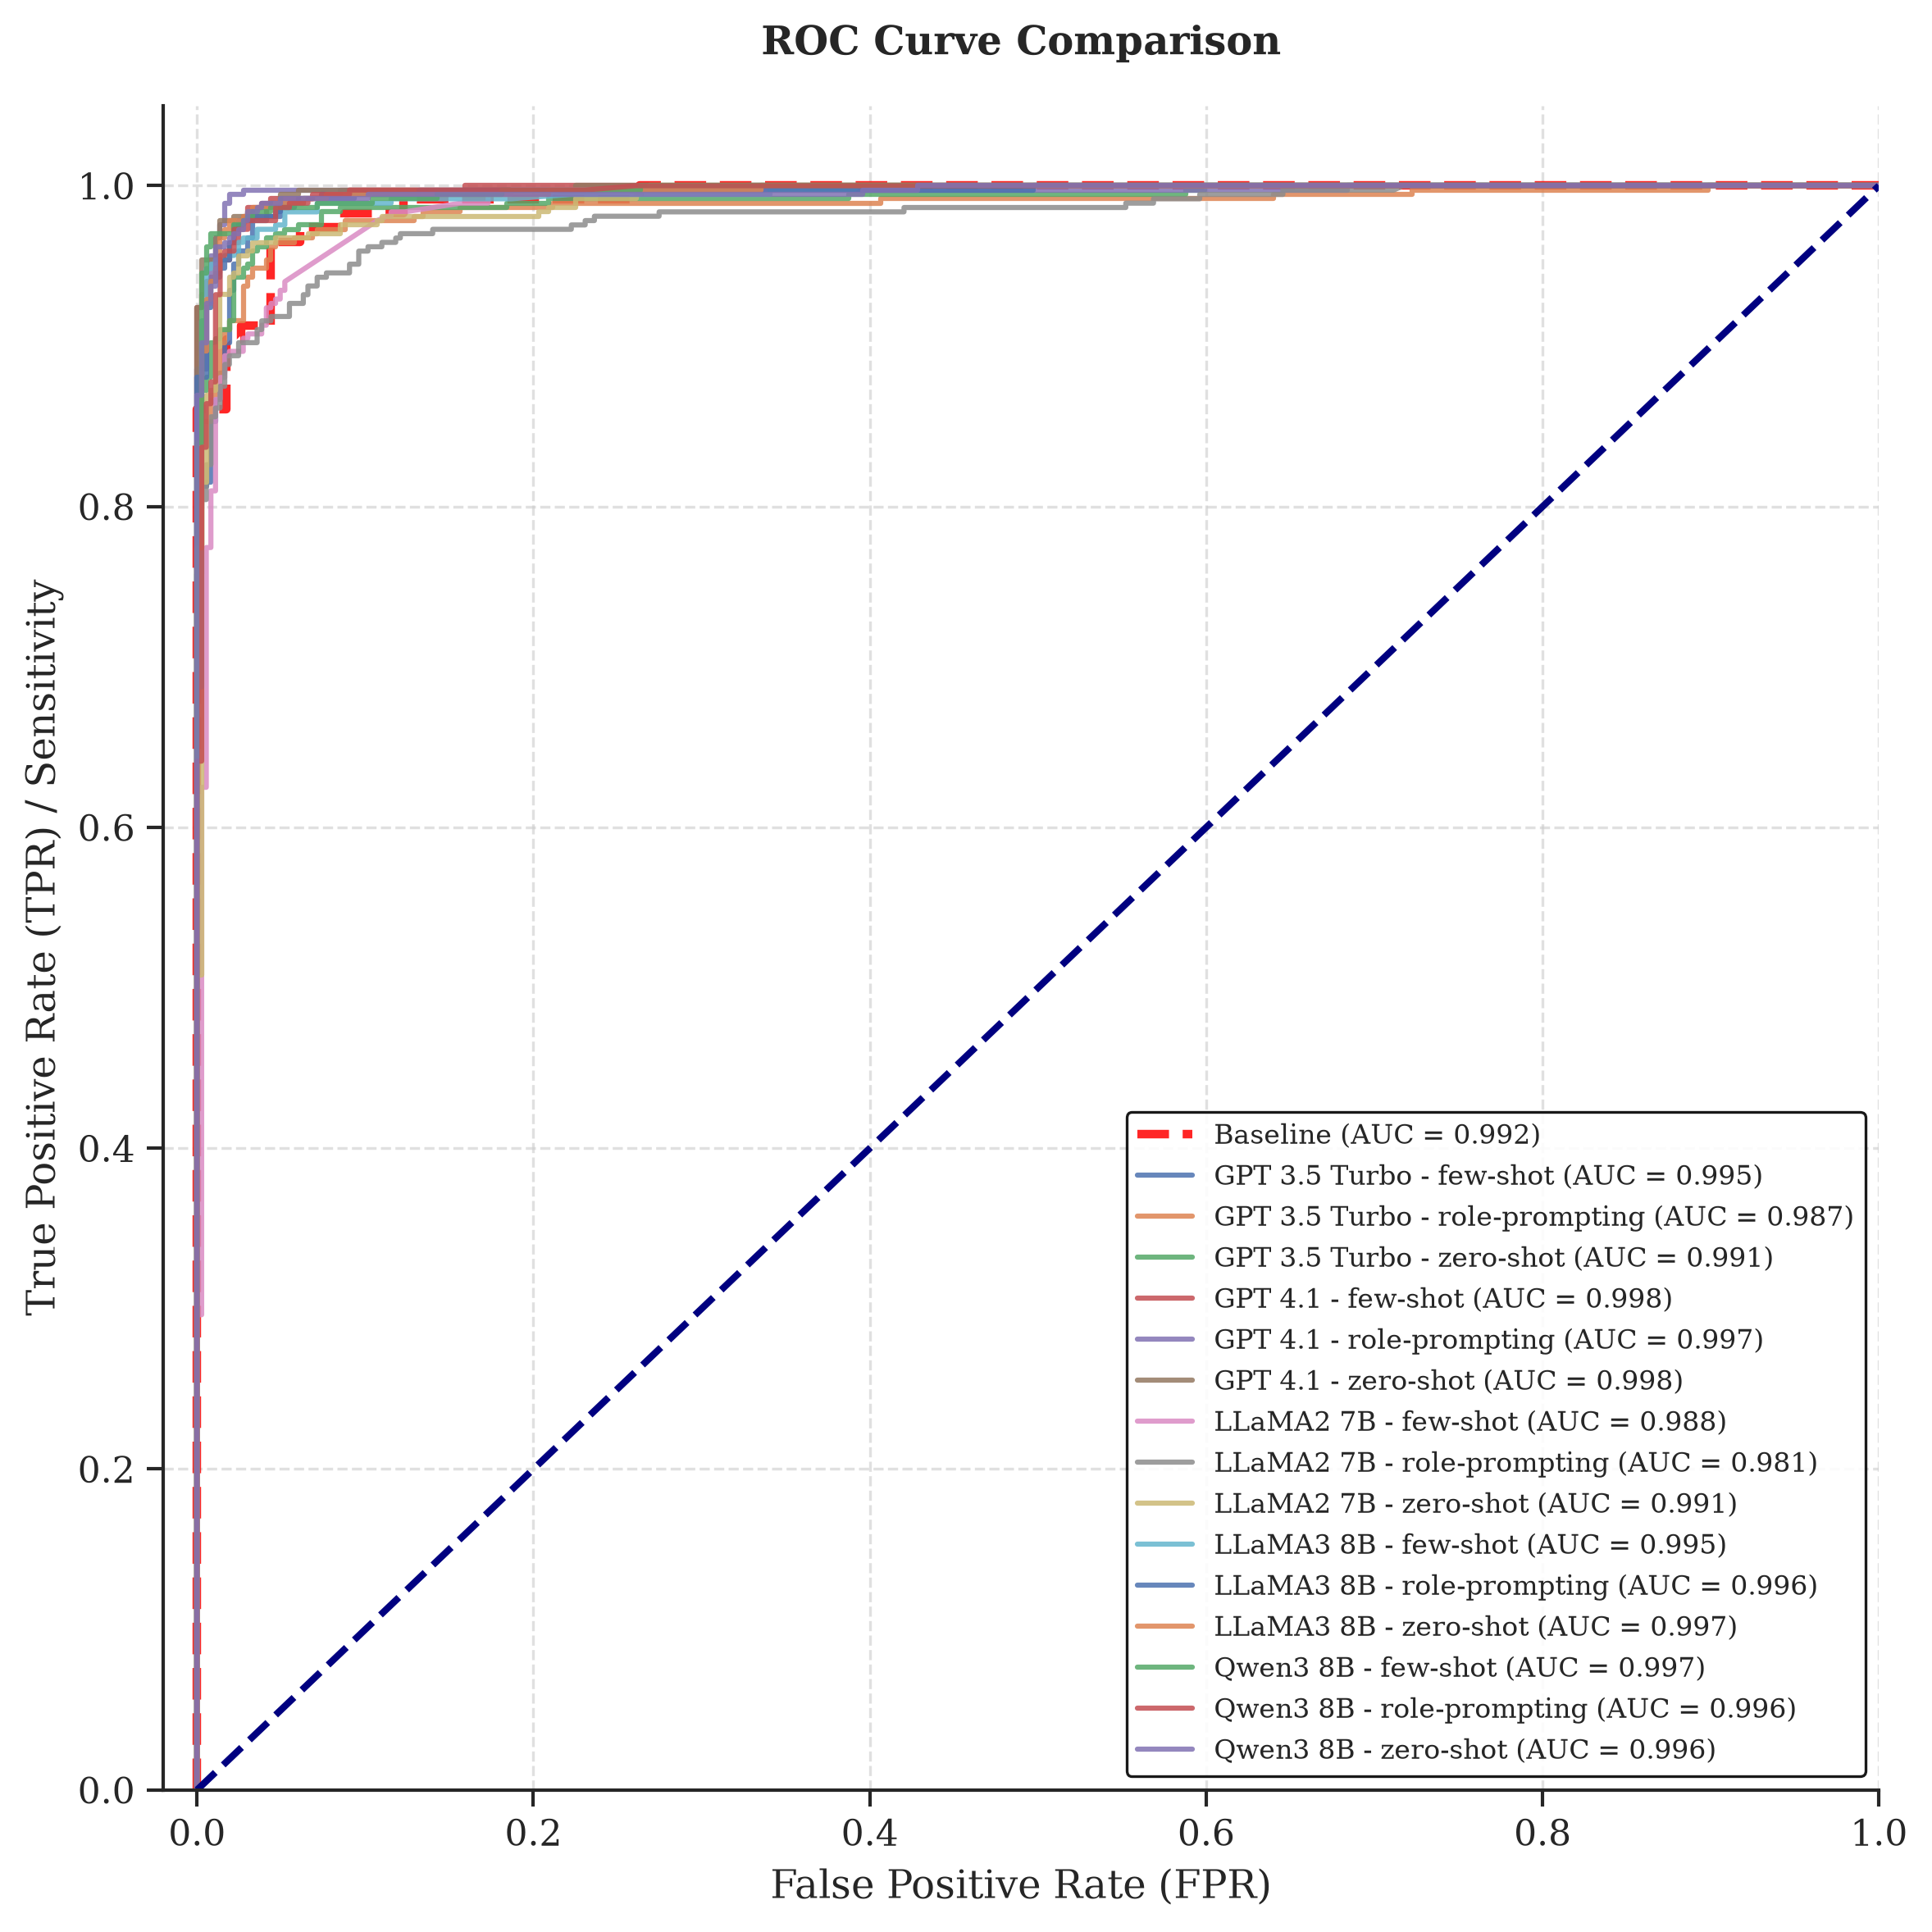

In [ ]:
TIMESTAMP = "20260913182453"
RAW_DATA_PATH = os.path.join("data", "raw", "sms_spam_indo.csv")
MERGED_DIR = os.path.join("data", "augmented", TIMESTAMP, "merged", "balanced")

print(f"Memproses data klasifikasi dari: {MERGED_DIR}")

def evaluate_classification(df):
    vectorizer = TfidfVectorizer(max_features=5000)
    X = vectorizer.fit_transform(df['Pesan'].astype(str)).toarray()
    y = df['Kategori'].map({'ham': 0, 'normal': 0, 'spam': 1}).values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
    xgb.fit(X_train, y_train)
    
    y_pred = xgb.predict(X_test)
    y_prob = xgb.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': auc(fpr, tpr),
        'fpr': fpr, 'tpr': tpr
    }

print("Melatih Model Klasifikasi XGBoost...")

results_list, roc_data = [], []
df_raw = pd.read_csv(RAW_DATA_PATH)
base_res = evaluate_classification(df_raw)
base_roc = {'Model': 'Baseline', 'Technique': 'None', 'fpr': base_res.pop('fpr'), 'tpr': base_res.pop('tpr'), 'auc': base_res['ROC-AUC']}
base_res.update({'Model': 'Baseline', 'Technique': 'None'})
results_list.append(base_res)
roc_data.append(base_roc)

for file in glob.glob(os.path.join(MERGED_DIR, "*.csv")):
    model_name, technique = parse_model_technique(os.path.basename(file))
    df_merged = pd.read_csv(file).dropna(subset=['Pesan', 'Kategori'])
    res = evaluate_classification(df_merged)
    roc_data.append({'Model': model_name, 'Technique': technique, 'fpr': res.pop('fpr'), 'tpr': res.pop('tpr'), 'auc': res['ROC-AUC']})
    res.update({'Model': model_name, 'Technique': technique})
    results_list.append(res)

df_clf = pd.DataFrame(results_list)[['Model', 'Technique', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]

export_table_to_png(df_clf.round(4), f"{TIMESTAMP}_tbl_classification.png", "XGBoost Classification Performance")
display(df_clf.round(4))

df_plot = df_clf[df_clf['Model'] != 'Baseline'].copy()
df_plot = df_plot.sort_values(by=['Model', 'Technique']) 
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
tech_palette = sns.color_palette("mako", n_colors=df_plot['Technique'].nunique())

for m in metrics:
    fig, ax = plt.subplots(figsize=(7, 5))
    baseline_val = df_clf[df_clf['Model'] == 'Baseline'][m].iloc[0]
    sns.barplot(data=df_plot, x='Model', y=m, hue='Technique', palette=tech_palette, ax=ax, zorder=2)
    ax.axhline(y=baseline_val, color='r', linestyle='--', label='Baseline', zorder=3)
    ax.set_title(f'Classification {m}', fontweight='bold', pad=15)
    ax.set_ylim(0.8, 1.02)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(output_fig_dir, f"{TIMESTAMP}_clf_{m.lower()}.png"))
    plt.close(fig)

fig_comb, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, m in enumerate(metrics):
    baseline_val = df_clf[df_clf['Model'] == 'Baseline'][m].iloc[0]
    sns.barplot(data=df_plot, x='Model', y=m, hue='Technique', palette=tech_palette, ax=axes[i], zorder=2)
    axes[i].axhline(y=baseline_val, color='r', linestyle='--', label='Baseline', zorder=3)
    axes[i].set_title(m, fontweight='bold')
    axes[i].set_ylim(0.8, 1.02)
    if i == 1: 
        axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.savefig(os.path.join(output_fig_dir, f"{TIMESTAMP}_clf_combined.png"))
print(f"[*] Grafik Gabungan Klasifikasi diekspor: {TIMESTAMP}_clf_combined.png")
plt.show()

plt.figure(figsize=(8, 8)) 

for data in roc_data:
    label = f"Baseline (AUC = {data['auc']:.3f})" if data['Model'] == 'Baseline' else f"{data['Model']} - {data['Technique']} (AUC = {data['auc']:.3f})"
    linestyle = '--' if data['Model'] == 'Baseline' else '-'
    linewidth = 2.5 if data['Model'] == 'Baseline' else 1.5
    color = 'red' if data['Model'] == 'Baseline' else None
    
    plt.plot(data['fpr'], data['tpr'], label=label, linestyle=linestyle, linewidth=linewidth, color=color, alpha=0.85)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Sensitivity')
plt.title('ROC Curve Comparison', fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(loc="lower right", fontsize=8, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.savefig(os.path.join(output_fig_dir, f"{TIMESTAMP}_roc_curve.png"), bbox_inches='tight')
print(f"[*] Grafik ROC Curve diekspor: {TIMESTAMP}_roc_curve.png")
plt.show()

Memproses Metrik Kualitas Teks (BERTScore, ROUGE-L, BLEU)...
[*] Tabel diekspor: results/tables/20260913182453_tbl_text_quality.png


,Model,Teknik,BERTScore,ROUGE-L,BLEU
0,GPT_3.5_Turbo,few-shot,0.7812,0.4816,0.1491
1,GPT_3.5_Turbo,role-prompting,0.7644,0.4146,0.1210
2,GPT_3.5_Turbo,zero-shot,0.7756,0.4512,0.1461
3,GPT_4.1,few-shot,0.8052,0.4957,0.1367
4,GPT_4.1,role-prompting,0.7995,0.4600,0.1141
5,GPT_4.1,zero-shot,0.8044,0.4778,0.1238
6,LLaMA2_7B,few-shot,0.8584,0.7020,0.5427
7,LLaMA2_7B,role-prompting,0.8168,0.6121,0.4256
8,LLaMA2_7B,zero-shot,0.8503,0.7045,0.4870
9,LLaMA3_8B,few-shot,0.8167,0.5999,0.2492


[*] Grafik Gabungan Kualitas Teks diekspor: 20260913182453_quality_combined.png


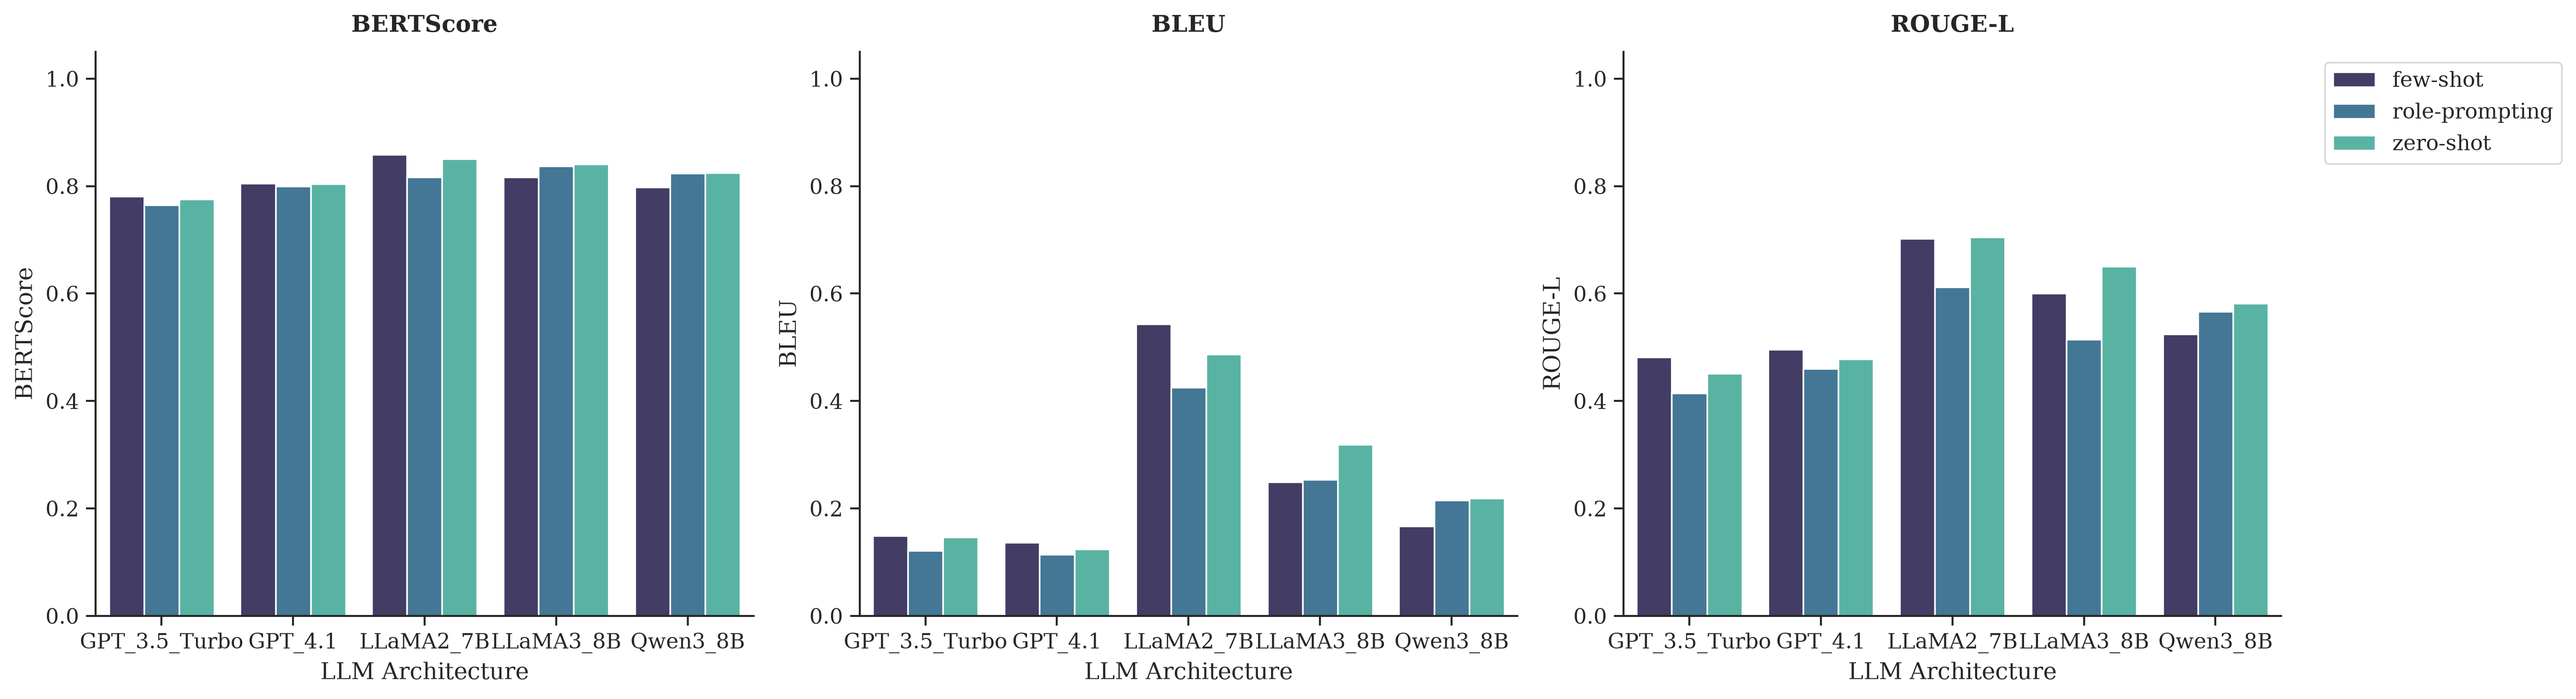

In [ ]:
print("Memproses Metrik Kualitas Teks (BERTScore, ROUGE-L, BLEU)...")

EVAL_DIR = os.path.join("results", "evaluation", f"{TIMESTAMP}-evaluation")
summary_path = os.path.join(EVAL_DIR, "Summary_TextQuality.csv")

if os.path.exists(summary_path):
    df_quality = pd.read_csv(summary_path)
    
    cols_to_keep = ['Model', 'Technique', 'BERT_score', 'ROUGE_score', 'BLEU']
    df_quality_clean = df_quality[cols_to_keep].copy()
    df_quality_clean.rename(columns={'BERT_score': 'BERTScore', 'ROUGE_score': 'ROUGE-L'}, inplace=True)
    
    export_table_to_png(df_quality_clean.round(4), f"{TIMESTAMP}_tbl_text_quality.png", "Synthetic Text Quality Metrics")
    display(df_quality_clean.round(4))

    df_plot_q = df_quality_clean.sort_values(by=['Model', 'Technique'])
    tech_palette = sns.color_palette("mako", n_colors=df_plot_q['Technique'].nunique())
    metrics_q = ['BERTScore', 'BLEU', 'ROUGE-L']

    for m in metrics_q:
        fig, ax = plt.subplots(figsize=(7, 5))
        sns.barplot(data=df_plot_q, x='Model', y=m, hue='Technique', palette=tech_palette, ax=ax, edgecolor='white')
        ax.set_title(f'{m} Score', fontweight='bold', pad=15)
        ax.set_ylabel('Score')
        ax.set_xlabel('LLM Architecture')
        ax.set_ylim(0, 1.05)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(os.path.join(output_fig_dir, f"{TIMESTAMP}_quality_indv_{m.lower().replace('-', '_')}.png"))
        plt.close(fig)

    fig_comb, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, m in enumerate(metrics_q):
        sns.barplot(data=df_plot_q, x='Model', y=m, hue='Technique', palette=tech_palette, ax=axes[i], edgecolor='white')
        axes[i].set_title(m, fontweight='bold', pad=10)
        axes[i].set_ylim(0, 1.05)
        axes[i].set_xlabel('LLM Architecture')
        if i == 2:
            axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            axes[i].get_legend().remove()

    plt.tight_layout()
    plt.savefig(os.path.join(output_fig_dir, f"{TIMESTAMP}_quality_combined.png"))
    print(f"[*] Grafik Gabungan Kualitas Teks diekspor: {TIMESTAMP}_quality_combined.png")
    plt.show()

else:
    print(f"[!] ERROR: File {summary_path} tidak ditemukan.")

In [ ]:
import random

def export_showcase_table(df, filename, title=None, wrap_width=90):
    df_wrapped = df.copy()
    
    df_wrapped['Teks Pesan'] = df_wrapped['Teks Pesan'].apply(lambda x: textwrap.fill(str(x), width=wrap_width))
    
    fig_height = sum([str(text).count('\n') + 1 for text in df_wrapped['Teks Pesan']]) * 0.4 + 2
    fig, ax = plt.subplots(figsize=(12, fig_height))
    ax.axis('off')
    if title:
        ax.set_title(title, fontweight='bold', fontsize=14, pad=15)
    
    table = ax.table(cellText=df_wrapped.values, colLabels=df_wrapped.columns, cellLoc='left', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    
    for (i, j), cell in table.get_celld().items():
        cell.set_edgecolor('#d3d3d3')
        cell.PAD = 0.08
        if i == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f2f2f2')
            cell.set_height(0.1)
        else:     
            num_lines = str(df_wrapped.iloc[i-1, j]).count('\n') + 1
            cell.set_height(0.06 * num_lines)
        
        if j == 0: cell.set_width(0.15)
        if j == 1: cell.set_width(0.85)
            
    plt.savefig(os.path.join(output_tbl_dir, filename), bbox_inches='tight', dpi=300)
    plt.close()

LOG_DIR = os.path.join("data", "augmented", TIMESTAMP, "augmented_log")
log_files = glob.glob(os.path.join(LOG_DIR, "*.csv"))

if log_files:
    sample_df = pd.read_csv(log_files[0])
    target_original = random.choice(sample_df['original'].dropna().tolist())
    print(f"Memantau Variasi untuk Teks Original:\n\"{target_original[:100]}...\"\n")

    for file in log_files:
        model_name, technique = parse_model_technique(os.path.basename(file))
        try:
            df_log = pd.read_csv(file)
            if 'original' not in df_log.columns: continue
                
            target_row = df_log[df_log['original'] == target_original]
            if not target_row.empty:
                target_row = target_row.iloc[0]
                para_cols = [c for c in df_log.columns if c.startswith('parafrase_')]
                variants = [target_row[c] for c in para_cols if pd.notnull(target_row[c]) and str(target_row[c]).strip() != ""]
                
                while len(variants) < 3: variants.append("-")
                variants = variants[:3]
                
                df_variance = pd.DataFrame({
                    "Tipe": ["Original Data", "Variant 1", "Variant 2", "Variant 3"],
                    "Teks Pesan": [target_original] + variants
                })
                
                clean_model_name = model_name.replace(' ', '_')
                table_filename = f"{TIMESTAMP}_variance_{clean_model_name}_{technique}.png"
                title_str = f"Text Generation Variance - Model: {model_name} | Technique: {technique}"
                
                export_showcase_table(df_variance, table_filename, title=title_str, wrap_width=95)
                print(f"[*] Tabel Diekspor: {table_filename}")
                display(df_variance)
                
        except Exception as e:
            pass
else:
    print(f"[!] Direktori log tidak ditemukan: {LOG_DIR}")

Memantau Variasi untuk Teks Original:
"PT.TRI CARE Selamat!!! simcard anda mendapatkan hadiah 1 Unit TOYOTA AVANZA Dengan pin: (F8HJ7TL) un..."

[*] Tabel Diekspor: 20260913182453_variance_GPT_3.5_Turbo_few-shot.png


,Tipe,Teks Pesan
0,Original Data,PT.TRI CARE Selamat!!! simcard anda mendapatka...
1,Variant 1,Selamat! Simcard kamu dapat hadiah 1 unit Toyo...
2,Variant 2,Selamat! Kamu beruntung dapat hadiah 1 unit To...
3,Variant 3,Kamu beruntung! Simcard kamu dapat hadiah 1 Un...


[*] Tabel Diekspor: 20260913182453_variance_GPT_3.5_Turbo_role-prompting.png


,Tipe,Teks Pesan
0,Original Data,PT.TRI CARE Selamat!!! simcard anda mendapatka...
1,Variant 1,"Wah, dapet hadiah mobil Toyota Avanza nih dari..."
2,Variant 2,"Mantap! Selamat ya atas hadiahnya, semoga bisa..."
3,Variant 3,Selamat! Anda telah berhasil memenangkan hadia...


[*] Tabel Diekspor: 20260913182453_variance_GPT_3.5_Turbo_zero-shot.png


...

,Tipe,Teks Pesan
0,Original Data,PT.TRI CARE Selamat!!! simcard anda mendapatka...
1,Variant 1,Selamat! SIM card Anda berhak mendapatkan 1 un...
2,Variant 2,Yey! SIM card kamu berhak mendapat hadiah 1 un...
3,Variant 3,Hei! Kartu SIM kamu dapat hadiah 1 unit Toyota...


[*] Tabel Diekspor: 20260913182453_variance_Qwen3_8B_role-prompting.png


,Tipe,Teks Pesan
0,Original Data,PT.TRI CARE Selamat!!! simcard anda mendapatka...
1,Variant 1,PT.TRI CARE Selamat!!! SIM Anda berhak mendapa...
2,Variant 2,PT.TRI CARE Horee!!! SIM card Anda berhak mend...
3,Variant 3,PT.TRI CARE Selamat berpartisipasi!!! Simcard ...


[*] Tabel Diekspor: 20260913182453_variance_Qwen3_8B_zero-shot.png


,Tipe,Teks Pesan
0,Original Data,PT.TRI CARE Selamat!!! simcard anda mendapatka...
1,Variant 1,PT.TRI CARE Hehe nanti dapat hadiah 1 unit TOY...
2,Variant 2,PT.TRI CARE Selamat! Simcard kamu dapat hadiah...
3,Variant 3,PT.TRI CARE Selamat! simcard kamu dapat hadiah...
